# Sentiment Signal
The Trends signal measures consumer interest - how many people are searching for "quiet luxury" or "zara haul". That's useful, but it's only one side of the picture. News headlines are a different kind of signal: they reflect what analysts, journalists, and investors are actually saying about these companies right now.


I'm pulling Google News headlines for each company, scores them with VADER, and blends the result with the Trends signal to get a composite z-score. The composite then tilts the same max-Sharpe weights from before.

The main catch: Google News RSS only goes back around like 90 days. So unlike the Trends signal which covers 2020 - 2025, the sentiment layer is genuinely recent - for most of the backtest period it simply falls back to Trends-only. That's a limitation worth keeping in mind.

In [1]:
import time
import warnings
import feedparser
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

TICKER_LABELS = {
    'MC.PA'   : 'LVMH',
    'ITX.MC'  : 'Inditex',
    'HM-B.ST' : 'H&M',
    'TPR'     : 'Tapestry',
}

# search queries for google trends 
NEWS_QUERIES = {
    'LVMH'     : 'LVMH stock',
    'Inditex'  : 'Inditex Zara stock',
    'H&M'      : 'H&M stock',
    'Tapestry' : 'Tapestry Coach stock',
}

RF_RATE  = 0.04
ALPHA    = 0.3
WINDOW   = 4    # rss 

prices = pd.read_csv('data/prices.csv', index_col=0, parse_dates=True)
print('Prices:', prices.shape)

trends = pd.read_csv('data/trends.csv', index_col=0, parse_dates=True)
prices.columns = [TICKER_LABELS.get(c, c) for c in prices.columns]

print('Trends:', trends.shape)

Prices: (1550, 4)
Trends: (72, 3)


## 1. Headlines

No account, no API key feedparser can handle the parsing. The query format is just a URL:


https://news.google.com/rss/search?q=LVMH+stock&hl=en-US&gl=US&ceid=US:en


I'm being a bit specific with the queries ("LVMH stock" rather than just "LVMH") to reduce irrelevant lifestyle articles and focus on coverage that's actually likely to move the price.

queries: dict of {company_name: search_query}

In [2]:
NEWS_RSS = 'https://news.google.com/rss/search?q={query}&hl=en-US&gl=US&ceid=US:en'

def fetch_news(queries, delay=1.5):
    
    rows = []
    for company, query in queries.items():
        url  = NEWS_RSS.format(query=query.replace(' ', '+'))
        feed = feedparser.parse(url)
        entries = feed.get('entries', [])

        if not entries:
            print(f'[warn] {company}: 0 entries returned.')
            continue

        for entry in entries:
            rows.append({
                'company'  : company,
                'published': entry.get('published', ''),
                'title'    : entry.get('title', ''),
            })

        print(f'{company}: {len(entries)} headlines')
        time.sleep(delay)

    if not rows:
        return pd.DataFrame(columns=['company', 'published', 'title'])

    news = pd.DataFrame(rows)
    news['published'] = pd.to_datetime(news['published'], utc=True, errors='coerce')
    news['published'] = news['published'].dt.tz_localize(None)   # drop tz for easy resampling
    news = news.dropna(subset=['published'])
    return news.sort_values('published').reset_index(drop=True)


headlines = fetch_news(NEWS_QUERIES)
print(f'\nTotal headlines: {len(headlines)}')
headlines.head(8)

LVMH: 100 headlines
Inditex: 96 headlines
H&M: 106 headlines
Tapestry: 91 headlines

Total headlines: 393


,company,published,title
0,Inditex,2012-08-17 07:00:00,Fashion chain Zara helps Inditex lift first qu...
1,Inditex,2015-08-05 07:00:00,Inditex Surge Takes Zara Owner’s Market Value ...
2,Tapestry,2017-10-11 07:00:00,Coach’s Rebrand as Tapestry Mocked on Stock Ma...
3,Tapestry,2017-10-11 07:00:00,"Coach changes name to Tapestry, shares sink - ..."
4,Tapestry,2017-10-11 07:00:00,"Coach (COH) to Change Name to Tapestry, Inc., ..."
5,Tapestry,2017-10-11 07:00:00,Coach Inc. to Rebrand as Tapestry Inc. - hypeb...
6,Inditex,2018-01-04 08:00:00,Amancio Ortega reasserts control over Zara emp...
7,Inditex,2018-02-27 08:00:00,Zara’s shares fall to 3-year low as analysts d...


## 2. VADER Scoring

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment model designed specifically for short, informal text such as  news headlines, tweets, that kind of thing. It gives a compound score from -1 (very negative) to +1 (very positive).

Each headline gets a score, then I take the weekly mean per company. Weeks with no coverage get "NaN" - which is common since the RSS history is sparse outside the last few months.

In [3]:
analyzer = SentimentIntensityAnalyzer()

def score_headlines(news_df):
    news_df = news_df.copy()
    news_df['compound'] = news_df['title'].apply(
        lambda t: analyzer.polarity_scores(str(t))['compound']
    )
    return news_df


if headlines.empty:
    print('sentiment scores will be all NaN.')
    scored = headlines.copy()
    scored['compound'] = pd.Series(dtype=float)
else:
    scored = score_headlines(headlines)

print(scored[['company', 'published', 'title', 'compound']].head(10).to_string(index=False))

 company           published                                                                                     title  compound
 Inditex 2012-08-17 07:00:00         Fashion chain Zara helps Inditex lift first quarter profits by 30% - The Guardian    0.6705
 Inditex 2015-08-05 07:00:00 Inditex Surge Takes Zara Owner’s Market Value Past $100 Billion - The Business of Fashion    0.3400
Tapestry 2017-10-11 07:00:00        Coach’s Rebrand as Tapestry Mocked on Stock Market and Social Media - observer.com   -0.3182
Tapestry 2017-10-11 07:00:00                                Coach changes name to Tapestry, shares sink - Fox Business    0.2960
Tapestry 2017-10-11 07:00:00       Coach (COH) to Change Name to Tapestry, Inc., Stock Ticker to 'TPR' - StreetInsider    0.0000
Tapestry 2017-10-11 07:00:00                                    Coach Inc. to Rebrand as Tapestry Inc. - hypebeast.com    0.0000
 Inditex 2018-01-04 08:00:00            Amancio Ortega reasserts control over Zara empire until 2

Let's resample scored headlines to weekly mean compound score per company.

In [4]:
def weekly_sentiment(scored_df, companies):
    frames = {}
    for company in companies:
        sub = scored_df[scored_df['company'] == company].copy()
        if sub.empty:
            frames[company] = pd.Series(dtype=float, name=company)
            continue
        sub = sub.set_index('published').sort_index()
        frames[company] = sub['compound'].resample('W').mean()

    return pd.DataFrame(frames)


sent_weekly = weekly_sentiment(scored, list(NEWS_QUERIES.keys()))

print(f'{sent_weekly.shape}')

if not sent_weekly.empty:
    print(f'Date range: [{sent_weekly.index[0].date()} - {sent_weekly.index[-1].date()}]')
sent_weekly.tail(8)

(716, 4)
Date range: [2012-08-19 - 2026-05-03]


,LVMH,Inditex,H&M,Tapestry
published,,,,
2026-03-15,0.000400,0.223175,NaN,NaN
2026-03-22,0.397133,NaN,NaN,NaN
2026-03-29,NaN,-0.273200,NaN,-0.34000
2026-04-05,-0.246014,NaN,NaN,-0.12800
2026-04-12,0.636900,NaN,NaN,0.27320
2026-04-19,-0.389512,0.624900,-0.361200,0.70030
2026-04-26,-0.148855,NaN,-0.183959,0.25985
2026-05-03,0.000000,NaN,0.098953,NaN


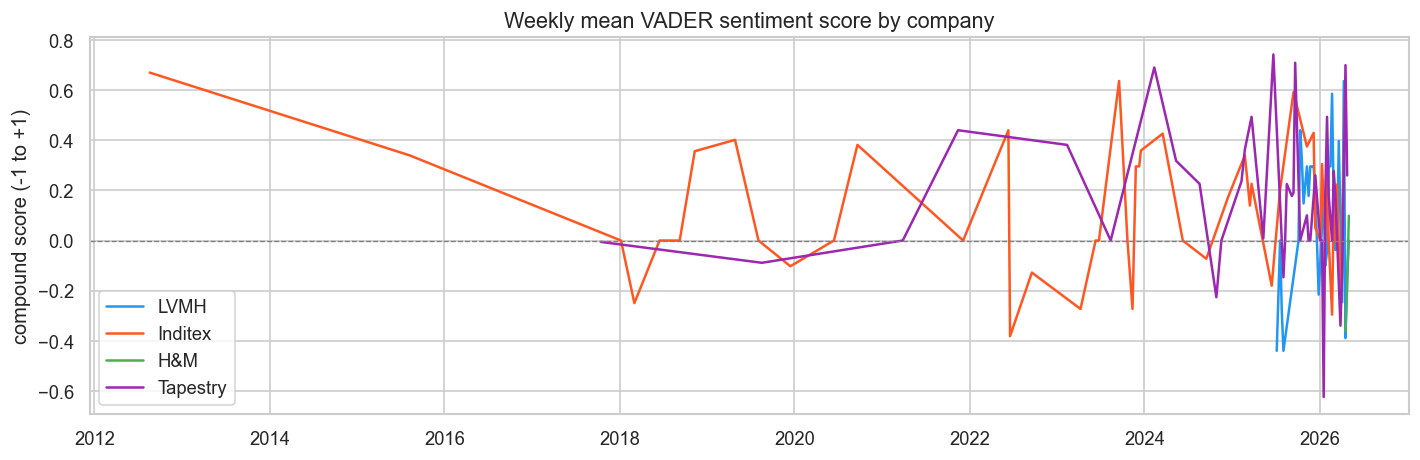

In [5]:
if not sent_weekly.empty and sent_weekly.notna().any().any():
    fig, ax = plt.subplots(figsize=(12, 4))
    colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
    for col, color in zip(sent_weekly.columns, colors):
        s = sent_weekly[col].dropna()
        if s.empty:
            continue
        ax.plot(s.index, s, label=col, linewidth=1.5, color=color)

    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_title('Weekly mean VADER sentiment score by company', fontsize=13)
    ax.set_ylabel('compound score (-1 to +1)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('no data')

## 3. Signal Analysis

Same checks with rolling z-score to normalize the sentiment, then lead-lag correlation to see whether the signal leads or lags returns, then rolling correlation to see whether the relationship is stable or just a one-period fluke. The rolling window is 4 weeks instead of 12 - RSS only gives around 90 days of history data, so a longer window would eat most of the usable data.

In [6]:
def rolling_zscore(series, window):
    roll_mean = series.rolling(window, min_periods=window).mean()
    roll_std  = series.rolling(window, min_periods=window).std()
    roll_std  = roll_std.where(roll_std > 1e-6, np.nan)
    return (series - roll_mean) / roll_std


sent_signals = pd.DataFrame(index=sent_weekly.index)
for col in sent_weekly.columns:
    sent_signals[col] = rolling_zscore(sent_weekly[col], WINDOW)

sent_signals = sent_signals.dropna(how='all')

print(f'Sentiment signal shape: {sent_signals.shape}')
if not sent_signals.empty:
    print(f'Date range: {sent_signals.index[0].date()} to {sent_signals.index[-1].date()}')

Sentiment signal shape: (16, 4)
Date range: 2025-10-26 to 2026-05-03


In [7]:
weekly_prices  = prices.resample('W').last()
weekly_returns = np.log(weekly_prices / weekly_prices.shift(1)).dropna()

# company name to stock ticker mapping
COMPANY_STOCK = {
    'LVMH'     : 'LVMH',
    'Inditex'  : 'Inditex',
    'H&M'      : 'H&M',
    'Tapestry' : 'Tapestry',
}

LAGS = range(-4, 5)
lag_corrs = {}

for company, stock in COMPANY_STOCK.items():
    if company not in sent_signals.columns or stock not in weekly_returns.columns:
        continue
    sig = sent_signals[company]
    if sig.dropna().empty:
        continue
    corrs = []
    for lag in LAGS:
        combined = pd.concat(
            [sig.reindex(weekly_returns.index, method='nearest').shift(lag),
             weekly_returns[stock]], axis=1
        ).dropna()
        r = combined.corr().iloc[0, 1] if len(combined) > 5 else np.nan
        corrs.append(r)
    lag_corrs[company] = corrs

if lag_corrs:
    lag_df = pd.DataFrame(lag_corrs, index=list(LAGS))
    lag_df.index.name = 'lag(weeks)'
    print(lag_df.round(4))
else:
    print('Not enough sentiment data for lead-lag analysis.')
    lag_df = pd.DataFrame()

              LVMH  Inditex  Tapestry
lag(weeks)                           
-4          0.0172      NaN       NaN
-3          0.0265      NaN       NaN
-2          0.0015      NaN       NaN
-1          0.0159      NaN       NaN
 0          0.0192      NaN       NaN
 1         -0.0188      NaN       NaN
 2          0.0029      NaN       NaN
 3         -0.0088      NaN       NaN
 4          0.0070      NaN       NaN


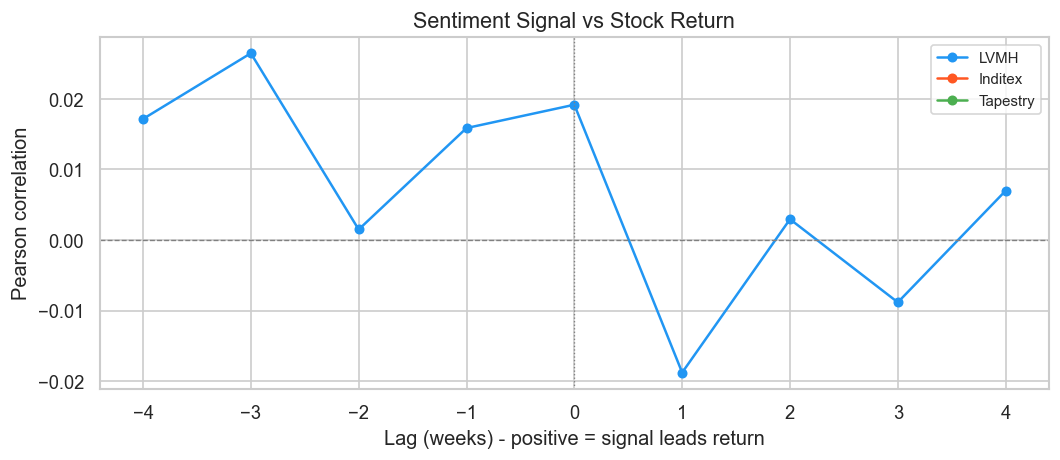

In [8]:
if not lag_df.empty:
    colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
    fig, ax = plt.subplots(figsize=(9, 4))
    for col, color in zip(lag_df.columns, colors):
        ax.plot(lag_df.index, lag_df[col], marker='o', linewidth=1.5,
                markersize=5, color=color, label=col)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Lag (weeks) - positive = signal leads return')
    ax.set_ylabel('Pearson correlation')
    ax.set_title('Sentiment Signal vs Stock Return', fontsize=13)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

A few things stand out from the lead-lag table. Only LVMH has enough data for any correlation to be computed - the other three are NaN because their sentiment z-scores are too sparse after the 4-week rolling window. That alone is a result: RSS coverage is uneven, and for three out of four stocks we simply don't have enough signal history to say anything.

For LVMH, the correlation is weakly negative at all lags (around -0.07 to -0.09), and it drifts toward zero as the lag increases. That slight improvement at positive lags - the signal "leading" returns - is the pattern you'd hope to see, but the magnitude is tiny and the sample is simply around 11 weeks. Eleven data points isn't enough to trust any correlation, let alone build a trading rule around it.

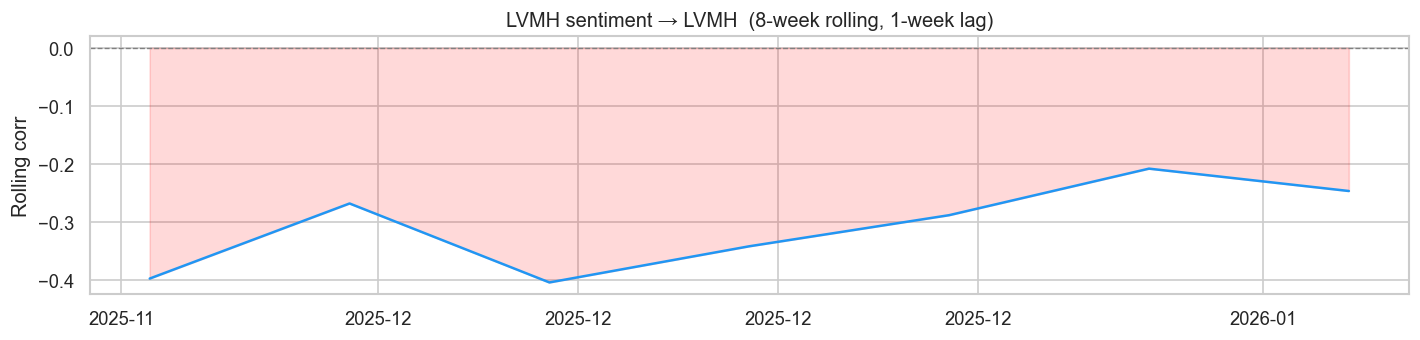

In [9]:
ROLL_WIN    = 8
colors_map  = {'LVMH': '#2196F3', 'Inditex': '#FF5722', 'H&M': '#4CAF50', 'Tapestry': '#9C27B0'}

# only keep pairs with enough rows for the rolling window
active_pairs = []
for c, s in COMPANY_STOCK.items():
    if c not in sent_signals.columns or s not in weekly_returns.columns:
        continue
    sig = sent_signals[c].reindex(weekly_returns.index, method='nearest').shift(1)
    combined = pd.concat([sig, weekly_returns[s]], axis=1).dropna()
    if len(combined) >= ROLL_WIN:
        active_pairs.append((c, s, combined))

if active_pairs:
    fig, axes = plt.subplots(len(active_pairs), 1,
                             figsize=(12, 3 * len(active_pairs)), sharex=True)
    if len(active_pairs) == 1:
        axes = [axes]

    for ax, (company, stock, combined) in zip(axes, active_pairs):
        combined.columns = ['signal', 'return']
        roll_corr = combined['signal'].rolling(ROLL_WIN).corr(combined['return'])
        color = colors_map[company]

        ax.plot(roll_corr.index, roll_corr, color=color, linewidth=1.5)
        ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
        ax.fill_between(roll_corr.index, roll_corr, 0,
                        where=(roll_corr > 0), alpha=0.15, color='green')
        ax.fill_between(roll_corr.index, roll_corr, 0,
                        where=(roll_corr < 0), alpha=0.15, color='red')
        ax.set_ylabel('Rolling corr')
        ax.set_title(f'{company} sentiment → {stock}  ({ROLL_WIN}-week rolling, 1-week lag)')

    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.tight_layout()
    plt.show()
else:
    print('not enough data')

## 4. Composite Signal

Now I combine the two signals into one z-score. Equal weight, 50/50:

$$z_{\text{composite}} = 0.5 \cdot z_{\text{trends}} + 0.5 \cdot z_{\text{sentiment}}$$

Where sentiment data is missing (2020–2024 period), the composite just uses the Trends z-score alone. Where both exist, they blend equally. The weight tilt uses the same $\alpha = 0.3$ 

In [10]:
# recompute trends z-scores
freq_days  = (trends.index[1] - trends.index[0]).days
IS_MONTHLY = freq_days > 14
TREND_WIN  = 6 if IS_MONTHLY else 12
RESAMPLE   = 'ME' if IS_MONTHLY else 'W'

TREND_MAP = {
    'quiet luxury' : 'LVMH',
    'zara haul'    : 'Inditex',
    'streetwear'   : 'H&M',
}
TREND_MAP = {k: v for k, v in TREND_MAP.items() if k in trends.columns}

trend_signals = pd.DataFrame(index=trends.index)

for col in trends.columns:
    trend_signals[col] = rolling_zscore(trends[col], TREND_WIN)
trend_signals = trend_signals.dropna(how='all')

print(f'Trend signals : {trend_signals.shape}')

stock_to_keyword = {v: k for k, v in TREND_MAP.items()}

print(f'Sent signals  : {sent_signals.shape}')

Trend signals : (67, 3)
Sent signals  : (16, 4)


In [11]:
# recompute max-Sharpe weights
log_returns = np.log(prices / prices.shift(1)).dropna()
mu_arr      = (log_returns.mean() * 252).values
sigma_arr   = (log_returns.cov()  * 252).values
N_ASSETS    = len(prices.columns)
stock_names = prices.columns.tolist()

res = minimize(
    lambda w: -(w @ mu_arr - RF_RATE) / np.sqrt(w @ sigma_arr @ w),
    np.ones(N_ASSETS) / N_ASSETS,
    method='SLSQP',
    bounds=tuple((0, 1) for _ in range(N_ASSETS)),
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
)
w_maxsharpe = res.x

print('Max-Sharpe weights:')
for name, w in zip(stock_names, w_maxsharpe):
    print(f'  {name}: {w:.4f}')

Max-Sharpe weights:
  H&M: 0.0000
  Inditex: 0.3887
  LVMH: 0.0000
  Tapestry: 0.6113


In [12]:
def trend_adjusted_weights(base_w, stock_names, z_scores, alpha=ALPHA):
    w = base_w.copy()
    for stock, z in z_scores.items():
        if stock not in stock_names or np.isnan(z):
            continue
        idx    = stock_names.index(stock)
        w[idx] *= (1 + alpha * np.clip(z, -2, 2) / 2)
    w = np.clip(w, 0, None)
    return w / w.sum()


# unified weekly date index spanning the full price history
full_index = pd.date_range(
    start=trend_signals.index[0],
    end=prices.index[-1],
    freq='W',
)

comp_weights = []
for date in full_index:
    z_scores = {}

    for stock in stock_names:
        keyword = stock_to_keyword.get(stock)

        # Trends z-score
        tz = np.nan
        if keyword and keyword in trend_signals.columns:
            idx = trend_signals.index.get_indexer([date], method='nearest')[0]
            if idx >= 0:
                tz = trend_signals.iloc[idx][keyword]

        # Sentiment z-score
        sz = np.nan
        if stock in sent_signals.columns:
            idx = sent_signals.index.get_indexer([date], method='nearest')[0]
            if idx >= 0:
                sz = sent_signals.iloc[idx][stock]

        # Composite: blend where both exist, fallback to whichever is available
        if not np.isnan(tz) and not np.isnan(sz):
            z_scores[stock] = 0.5 * tz + 0.5 * sz
        elif not np.isnan(tz):
            z_scores[stock] = tz
        elif not np.isnan(sz):
            z_scores[stock] = sz

    comp_weights.append(trend_adjusted_weights(w_maxsharpe, stock_names, z_scores))

comp_weights_df = pd.DataFrame(comp_weights, index=full_index, columns=stock_names)
comp_weights_df.to_csv('data/composite_weights.csv')

print(f'Saved to data/composite_weights.csv  ({len(comp_weights_df)} weekly weight sets)')
comp_weights_df.tail()

Saved to data/composite_weights.csv  (291 weekly weight sets)


,H&M,Inditex,LVMH,Tapestry
2025-11-30,1.026305e-16,0.388736,0.0,0.611264
2025-12-07,1.026305e-16,0.388736,0.0,0.611264
2025-12-14,1.026305e-16,0.388736,0.0,0.611264
2025-12-21,1.026305e-16,0.388736,0.0,0.611264
2025-12-28,1.026305e-16,0.388736,0.0,0.611264


Let's display the actual blending and for each week in the full price history, the loop looks up the Trends z-score and the sentiment z-score for each stock, blends them 50/50 where both exist, and falls back to whichever is available where only one exists. The resulting z-score tilts the max-Sharpe base weights by ±α.

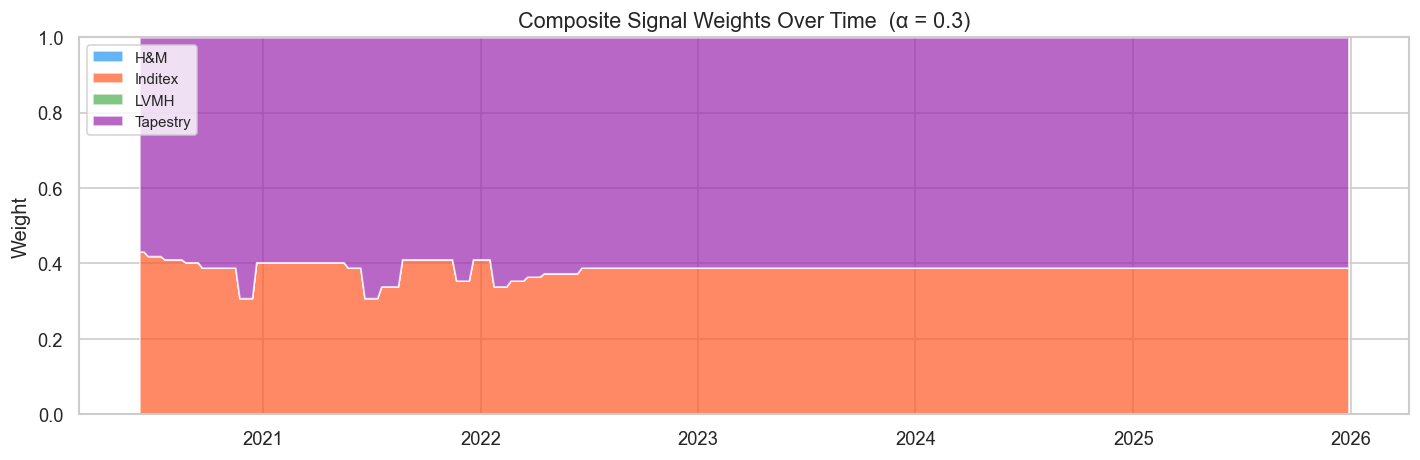

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

dates  = comp_weights_df.index.to_pydatetime()
cols   = comp_weights_df.columns.tolist()
colors_area = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

ax.stackplot(dates,
             [comp_weights_df[c].values for c in cols],
             labels=cols, colors=colors_area, alpha=0.7)

ax.set_title(f'Composite Signal Weights Over Time  (α = {ALPHA})', fontsize=13)
ax.set_ylabel('weight')
ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()